In [1]:
import pandas as pd
import numpy as np
import praw
from datetime import datetime

In [2]:
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
from datetime import datetime


In [3]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; AppleMapsSentiment/0.1; +https://example.com)"
}

def search_reddit_posts(subreddit: str, query: str, limit_posts: int = 3):
    """
    Small sample search using Reddit's public JSON endpoint.
    No API key needed.
    Returns a list of basic post info.
    """
    url = f"https://www.reddit.com/r/{subreddit}/search.json"
    params = {
        "q": query,
        "restrict_sr": 1,
        "sort": "relevance",  # or "new"
        "t": "all",
        "limit": limit_posts
    }
    
    print(f"[SEARCH] r/{subreddit}, query='{query}', limit={limit_posts}")
    resp = requests.get(url, headers=HEADERS, params=params)
    print("  Status:", resp.status_code)
    if resp.status_code != 200:
        print("  Non-200 response, returning empty list.")
        return []
    
    data = resp.json()
    children = data.get("data", {}).get("children", [])
    posts = []
    for child in children:
        post = child["data"]
        posts.append({
            "subreddit": subreddit,
            "post_id": post.get("id"),
            "title": post.get("title"),
            "selftext": post.get("selftext"),
            "score": post.get("score"),
            "num_comments": post.get("num_comments"),
            "created_utc": post.get("created_utc"),
            "created_date": datetime.fromtimestamp(post.get("created_utc", 0)),
            "url": "https://www.reddit.com" + post.get("permalink", ""),
        })
    return posts


def fetch_post_with_comments(post_id: str, max_comments: int = 10):
    """
    Fetch ONE Reddit thread (post + up to max_comments comments)
    using the public comments/{post_id}.json endpoint.
    No API key needed.
    """
    url = f"https://www.reddit.com/comments/{post_id}.json"
    resp = requests.get(url, headers=HEADERS)
    print(f"[COMMENTS] Fetching post_id={post_id}, status={resp.status_code}")
    if resp.status_code != 200:
        print("  Failed to fetch comments.")
        return None
    
    data = resp.json()
    if len(data) < 2:
        print("  Unexpected JSON structure.")
        return None
    
    # Post metadata
    try:
        post_data = data[0]["data"]["children"][0]["data"]
    except (IndexError, KeyError):
        print("  Could not parse post data.")
        return None
    
    # Comments
    comments_block = data[1]["data"]["children"]
    comments = []
    for c in comments_block:
        if c.get("kind") != "t1":  # t1 = comment node
            continue
        cdata = c.get("data", {})
        body = cdata.get("body")
        if body:
            comments.append(body.replace("\n", " "))
            if len(comments) >= max_comments:
                break
    
    row = {
        "post_id": post_id,
        "subreddit": post_data.get("subreddit"),
        "title": post_data.get("title"),
        "selftext": post_data.get("selftext"),
        "score": post_data.get("score"),
        "num_comments": post_data.get("num_comments"),
        "created_utc": post_data.get("created_utc"),
        "created_date": datetime.fromtimestamp(post_data.get("created_utc", 0)),
        "url": "https://www.reddit.com" + post_data.get("permalink", ""),
        "comments_joined": " ||| ".join(comments),
    }
    return row


In [4]:
subreddits = ["apple", "applemaps"]
query = "Apple Maps"

sample_posts = []

for sub in subreddits:
    posts = search_reddit_posts(sub, query, limit_posts=2)  # 2 posts per subreddit
    sample_posts.extend(posts)

len(sample_posts), sample_posts[:2]


[SEARCH] r/apple, query='Apple Maps', limit=2
  Status: 200
[SEARCH] r/applemaps, query='Apple Maps', limit=2
  Status: 200


(4,
 [{'subreddit': 'apple',
   'post_id': '1pa1e9w',
   'title': 'The EU says Apple Maps may be big enough to be considered a DMA gatekeeper',
   'selftext': '',
   'score': 1007,
   'num_comments': 355,
   'created_utc': 1764454499.0,
   'created_date': datetime.datetime(2025, 11, 29, 16, 14, 59),
   'url': 'https://www.reddit.com/r/apple/comments/1pa1e9w/the_eu_says_apple_maps_may_be_big_enough_to_be/'},
  {'subreddit': 'apple',
   'post_id': '1ogl1dq',
   'title': 'Apple Reportedly Moving Ahead With Ads in Maps App',
   'selftext': '',
   'score': 2378,
   'num_comments': 1017,
   'created_utc': 1761486414.0,
   'created_date': datetime.datetime(2025, 10, 26, 8, 46, 54),
   'url': 'https://www.reddit.com/r/apple/comments/1ogl1dq/apple_reportedly_moving_ahead_with_ads_in_maps_app/'}])

In [5]:
enriched_rows = []

for p in sample_posts:
    post_id = p["post_id"]
    detailed = fetch_post_with_comments(post_id, max_comments=10)
    if detailed:
        enriched_rows.append(detailed)
    time.sleep(1)  # polite delay

df_sample = pd.DataFrame(enriched_rows)
df_sample.shape, df_sample.head()


[COMMENTS] Fetching post_id=1pa1e9w, status=200
[COMMENTS] Fetching post_id=1ogl1dq, status=200
[COMMENTS] Fetching post_id=1opt8f2, status=200
[COMMENTS] Fetching post_id=1md7w5h, status=200


((4, 10),
    post_id  subreddit                                              title  \
 0  1pa1e9w      apple  The EU says Apple Maps may be big enough to be...   
 1  1ogl1dq      apple  Apple Reportedly Moving Ahead With Ads in Maps...   
 2  1opt8f2  applemaps                   What do you think of Apple Maps?   
 3  1md7w5h  applemaps  When did Apple Maps become better than google ...   
 
                                             selftext  score  num_comments  \
 0                                                      1000           355   
 1                                                      2374          1017   
 2  Right now, I’m debating with myself about whic...     20            48   
 3  Apple Maps shows a whole new entrance that goo...    407           110   
 
     created_utc        created_date  \
 0  1.764454e+09 2025-11-29 16:14:59   
 1  1.761486e+09 2025-10-26 08:46:54   
 2  1.762417e+09 2025-11-06 02:08:49   
 3  1.753885e+09 2025-07-30 09:21:24   
 
         

In [6]:


output_path = "../data/raw/reddit_apple_maps_sample_posts_comments.csv"
df_sample.to_csv(output_path, index=False, encoding="utf-8")
print("Saved to:", output_path)


Saved to: ../data/raw/reddit_apple_maps_sample_posts_comments.csv


In [ ]:
def fetch_threads(subreddit, query="Apple Maps", max_pages=20, limit=25, delay=1.5):
    url = f"https://www.reddit.com/r/{subreddit}/search.json"

    params = {
        "q": query,
        "restrict_sr": 1,
        "sort": "new",     # IMPORTANT → newest first
        "t": "year",       # keeps it reasonably recent
        "limit": limit
    }

    all_posts = []
    after = None
    page = 1

    while page <= max_pages:
        if after:
            params["after"] = after
        
        print(f"[SEARCH] r/{subreddit} page {page}")
        resp = requests.get(url, headers=HEADERS, params=params)
        if resp.status_code != 200:
            print("  Failed:", resp.status_code)
            break
        
        data = resp.json().get("data", {})
        children = data.get("children", [])
        if not children:
            print("  No posts returned. Stopping.")
            break

        stop_due_to_old_posts = False

        for c in children:
            p = c["data"]
            created_ts = p.get("created_utc", 0)
            created_dt = datetime.fromtimestamp(created_ts)

            # 🔴 HARD DATE STOP — if older than cutoff, stop scraping further
            if created_dt < CUTOFF_DATE:
                stop_due_to_old_posts = True
                break

            all_posts.append({
                "post_id": p["id"],
                "subreddit": subreddit,
                "title": p.get("title", ""),
                "selftext": p.get("selftext", ""),
                "score": p.get("score", 0),
                "num_comments": p.get("num_comments", 0),
                "created_utc": created_ts,
                "created_date": created_dt,
                "url": "https://www.reddit.com" + p.get("permalink", "")
            })

        if stop_due_to_old_posts:
            print("  Hit posts older than cutoff — stopping this subreddit.")
            break

        after = data.get("after")
        if not after:
            print("  No more pages (no 'after' token).")
            break
        
        page += 1
        time.sleep(delay)

    return all_posts


In [7]:
import os
import time
import requests
import pandas as pd
from datetime import datetime, timedelta

# =========================
# CONFIG
# =========================

HEADERS = {
    "User-Agent": "Mozilla/5.0 (AppleMapsExperienceStudy/1.0; +https://example.com)"
}

SUBREDDITS = ["apple", "applemaps", "iphone", "ios"]
QUERY = "Apple Maps"

# Limit to last 8 months
MONTHS_BACK = 8
CUTOFF_DATE = datetime.utcnow() - timedelta(days=30 * MONTHS_BACK)
print("Collecting posts after:", CUTOFF_DATE)

# Scraper parameters
MAX_PAGES_PER_SUB = 20      # hard upper bound, we stop earlier when we hit old posts
POSTS_PER_PAGE = 25         # JSON limit per request
SEARCH_DELAY = 1.5          # seconds between search requests
COMMENT_DELAY = 1.0         # seconds between comment requests
MAX_COMMENTS_PER_POST = 50  # cap comments per thread to keep data manageable

OUTPUT_PATH = "../data/raw/reddit_apple_maps_full_last8months.csv"


# =========================
# HELPER FUNCTIONS
# =========================

def fetch_threads(subreddit, query=QUERY, max_pages=MAX_PAGES_PER_SUB,
                  limit=POSTS_PER_PAGE, delay=SEARCH_DELAY):
    """
    Fetch threads from a subreddit about Apple Maps using Reddit's public JSON search.
    We:
      - sort by 'new' so newer posts come first
      - stop when we encounter posts older than CUTOFF_DATE
    Returns a list of post dicts (without comments).
    """
    url = f"https://www.reddit.com/r/{subreddit}/search.json"

    params = {
        "q": query,
        "restrict_sr": 1,
        "sort": "new",   # newest first
        "t": "year",     # rough server-side recency filter
        "limit": limit
    }

    all_posts = []
    after = None
    page = 1

    while page <= max_pages:
        if after:
            params["after"] = after

        print(f"[SEARCH] r/{subreddit} page {page}")
        resp = requests.get(url, headers=HEADERS, params=params)
        print("  Status:", resp.status_code)
        if resp.status_code != 200:
            print("  Non-200 status, stopping this subreddit.")
            break

        data = resp.json().get("data", {})
        children = data.get("children", [])
        if not children:
            print("  No posts returned, stopping this subreddit.")
            break

        # We will stop if we see posts older than cutoff
        stop_due_to_old_posts = False

        for c in children:
            p = c.get("data", {})
            created_ts = p.get("created_utc", 0)
            created_dt = datetime.fromtimestamp(created_ts)

            # Hard date limit: stop scraping once we reach posts older than cutoff
            if created_dt < CUTOFF_DATE:
                stop_due_to_old_posts = True
                break

            all_posts.append({
                "post_id": p.get("id", ""),
                "subreddit": subreddit,
                "title": p.get("title", "") or "",
                "selftext": p.get("selftext", "") or "",
                "score": p.get("score", 0),
                "num_comments": p.get("num_comments", 0),
                "created_utc": created_ts,
                "created_date": created_dt,
                "url": "https://www.reddit.com" + p.get("permalink", "")
            })

        if stop_due_to_old_posts:
            print("  Hit posts older than cutoff date – stopping this subreddit.")
            break

        after = data.get("after")
        if not after:
            print("  No 'after' token – no more pages for this subreddit.")
            break

        page += 1
        time.sleep(delay)

    print(f"  Collected {len(all_posts)} posts from r/{subreddit} (after cutoff filter).")
    return all_posts


def fetch_comments(post_id, max_comments=MAX_COMMENTS_PER_POST):
    """
    Fetch top-level comments for a Reddit thread using the public comments JSON endpoint.
    Returns a list of plain-text comment strings.
    """
    url = f"https://www.reddit.com/comments/{post_id}.json"
    resp = requests.get(url, headers=HEADERS)
    print(f"    [COMMENTS] post_id={post_id}, status={resp.status_code}")

    if resp.status_code != 200:
        print("    Failed to fetch comments.")
        return []

    try:
        data = resp.json()
    except ValueError:
        print("    Failed to parse JSON for comments.")
        return []

    # Comments are in the second element's data.children
    if len(data) < 2:
        print("    Unexpected JSON structure for comments.")
        return []

    comments = []
    try:
        children = data[1]["data"]["children"]
    except (KeyError, TypeError):
        print("    Could not access comments children.")
        return []

    for c in children:
        if c.get("kind") != "t1":  # t1 = comment
            continue
        cdata = c.get("data", {})
        body = (cdata.get("body") or "").strip()
        if not body:
            continue
        lower = body.lower()
        if lower in ("[deleted]", "[removed]"):
            continue

        comments.append(body)

        if len(comments) >= max_comments:
            break

    return comments


def run_scrape():
    """
    Main pipeline:
      - loops subreddits
      - fetches recent posts about Apple Maps
      - fetches up to MAX_COMMENTS_PER_POST comments per post
      - stores everything in a DataFrame and saves to CSV
    """
    all_rows = []

    for sub in SUBREDDITS:
        posts = fetch_threads(subreddit=sub)
        print(f"[INFO] r/{sub}: {len(posts)} recent posts to enrich with comments.\n")

        for p in posts:
            post_id = p["post_id"]
            print(f"  Getting comments for {post_id} (reported {p['num_comments']} comments)")
            comments = fetch_comments(post_id)
            p["comments"] = comments  # list of strings
            time.sleep(COMMENT_DELAY)
            all_rows.append(p)

    df = pd.DataFrame(all_rows)

    # Ensure folder exists
    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

    # Save
    df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
    print(f"\n✅ Saved dataset to: {OUTPUT_PATH}")
    print("Shape:", df.shape)
    return df


# =========================
# RUN SCRAPE
# =========================

df_full = run_scrape()

# Peek at what we got
df_full.head()


C:\Users\balaj\AppData\Local\Temp\ipykernel_51984\3293204070.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  CUTOFF_DATE = datetime.utcnow() - timedelta(days=30 * MONTHS_BACK)


[SEARCH] r/apple page 1
  Status: 200
[SEARCH] r/apple page 2
  Status: 200
  Hit posts older than cutoff date – stopping this subreddit.
  Collected 25 posts from r/apple (after cutoff filter).
[INFO] r/apple: 25 recent posts to enrich with comments.

  Getting comments for 1pqiqvw (reported 83 comments)
    [COMMENTS] post_id=1pqiqvw, status=200
  Getting comments for 1pgh00h (reported 30 comments)
    [COMMENTS] post_id=1pgh00h, status=200
  Getting comments for 1paorgu (reported 193 comments)
    [COMMENTS] post_id=1paorgu, status=200
  Getting comments for 1pakqjh (reported 14 comments)
    [COMMENTS] post_id=1pakqjh, status=200
  Getting comments for 1pa1e9w (reported 355 comments)
    [COMMENTS] post_id=1pa1e9w, status=200
  Getting comments for 1p8gdql (reported 37 comments)
    [COMMENTS] post_id=1p8gdql, status=200
  Getting comments for 1ogl1dq (reported 1017 comments)
    [COMMENTS] post_id=1ogl1dq, status=200
  Getting comments for 1o18hjl (reported 14 comments)
    [COMME

,post_id,subreddit,title,selftext,score,num_comments,created_utc,created_date,url,comments
0,1pqiqvw,apple,Apple Quietly Discontinued Flyover City Tours ...,,933,83,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,[I would rather have the ability to drive a ro...
1,1pgh00h,apple,Made an affordable app to add alarms to remind...,I made this app Cannot Ignore because now in i...,5,30,1.765110e+09,2025-12-07 06:16:43,https://www.reddit.com/r/apple/comments/1pgh00...,[You may have been partially sherlocked as 26....
2,1paorgu,apple,Apple Developing These 5 New Satellite Feature...,# Summary\n\nThe article describes five new sa...,561,193,1.764526e+09,2025-11-30 11:58:52,https://www.reddit.com/r/apple/comments/1paorg...,[What happened to weather over satellite? I wa...
3,1pakqjh,apple,Built my first Swift app as a professional cro...,Since moving to South Korea (from South Africa...,23,14,1.764516e+09,2025-11-30 09:18:16,https://www.reddit.com/r/apple/comments/1pakqj...,"[Looks great! I especially like the ""Import fr..."
4,1pa1e9w,apple,The EU says Apple Maps may be big enough to be...,,1003,355,1.764454e+09,2025-11-29 16:14:59,https://www.reddit.com/r/apple/comments/1pa1e9...,"[The EU hasn't said anything yet, after the in..."


In [8]:
# See columns
df_full.columns


Index(['post_id', 'subreddit', 'title', 'selftext', 'score', 'num_comments',
       'created_utc', 'created_date', 'url', 'comments'],
      dtype='object')

In [9]:
df_full[["title", "comments"]].head()


,title,comments
0,Apple Quietly Discontinued Flyover City Tours ...,[I would rather have the ability to drive a ro...
1,Made an affordable app to add alarms to remind...,[You may have been partially sherlocked as 26....
2,Apple Developing These 5 New Satellite Feature...,[What happened to weather over satellite? I wa...
3,Built my first Swift app as a professional cro...,"[Looks great! I especially like the ""Import fr..."
4,The EU says Apple Maps may be big enough to be...,"[The EU hasn't said anything yet, after the in..."


In [10]:
example_idx = 0  # change this to see different threads
print("Title:", df_full.loc[example_idx, "title"])
print("\nComments:\n")
for c in df_full.loc[example_idx, "comments"]:
    print("-", c)

Title: Apple Quietly Discontinued Flyover City Tours in Apple Maps

Comments:

- I would rather have the ability to drive a route in Maps. Apple Street View or whatever it's called is much superior to Google and would easily allow such a feature as you can basically do it now with tapping
- &gt;Apple Maps no longer offers a Flyover feature that provides users with automated tours of notable landmarks in major cities. The Flyover option appears to have been nixed around when iOS 26 launched, but its removal went largely unnoticed.

&gt;Flyover city tours were introduced in 2014 with iOS 8 and OS X Yosemite, using Flyover imagery to generate an aerial tour. Most cities with Flyover imagery supported the tour feature, but it may not have been used often since Apple was able to quietly discontinue it.

&gt;Flyover imagery has not been removed and over 350 cities continue to have 3D Flyover imagery that highlights landmarks, parks, important buildings, and more with a bird's-eye view.

&gt;

In [11]:
df_full.shape

(273, 10)

In [12]:
df_full.tail()

,post_id,subreddit,title,selftext,score,num_comments,created_utc,created_date,url,comments
268,1mo6jb3,applemaps,Shady business uses of Maps,"Hi everyone,\nI was wondering if there’s a way...",44,9,1.754999e+09,2025-08-12 06:49:48,https://www.reddit.com/r/applemaps/comments/1m...,[]
269,1mnemkm,applemaps,Is it time to switch to Apple Maps?,"As a Google maps user for 6 years, I have foun...",186,57,1.754923e+09,2025-08-11 09:33:32,https://www.reddit.com/r/applemaps/comments/1m...,[]
270,1mn3os3,applemaps,Apple Maps’s secret speedometer,(Confirm to be Chinese exclusive on national h...,54,16,1.754887e+09,2025-08-10 23:34:16,https://www.reddit.com/r/applemaps/comments/1m...,[]
271,1mm4guo,applemaps,Apple Maps place issue,I’ve added a missing place and the next day I ...,19,7,1.754785e+09,2025-08-09 19:17:28,https://www.reddit.com/r/applemaps/comments/1m...,[]
272,1mlxoup,applemaps,Help: UK holiday coming from the continent.,How do I change the driving direction? I usual...,0,9,1.754767e+09,2025-08-09 14:15:52,https://www.reddit.com/r/applemaps/comments/1m...,[]


In [13]:
df_full["created_date"].min(), df_full["created_date"].max()


(Timestamp('2025-05-14 14:18:56'), Timestamp('2025-12-31 13:49:32'))

In [16]:
output_path = "../data/raw/apple_maps_reddit.csv"
df_full.to_csv(output_path, index=False, encoding="utf-8")
print("Saved:", output_path)


Saved: ../data/raw/apple_maps_reddit.csv


In [18]:
def is_maps_related(row):
    text = ""
    
    # include title + body
    if isinstance(row["title"], str):
        text += " " + row["title"].lower()
    if isinstance(row["selftext"], str):
        text += " " + row["selftext"].lower()

    # flatten comments into text (lightweight check)
    if isinstance(row["comments"], list):
        joined_comments = " ".join([str(c).lower() for c in row["comments"][:20]])
        text += " " + joined_comments
    
    keywords = [
        "apple maps",
        "maps app",
        "navigation",
        "carplay maps",
        "carplay navigation",
        "directions",
        "routing",
        "route",
        "traffic",
        "eta",
        "turn by turn",
        "poi",
        "places",
        "business listing",
        "michelin",
        "transit",
        "cycling directions",
        "map data",
        "street view",
        "look around"
    ]
    
    return any(k in text for k in keywords)

df_maps = df_full[df_full.apply(is_maps_related, axis=1)].copy()

df_maps.shape


(257, 10)

In [19]:
df_maps

,post_id,subreddit,title,selftext,score,num_comments,created_utc,created_date,url,comments
0,1pqiqvw,apple,Apple Quietly Discontinued Flyover City Tours ...,,933,83,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,[I would rather have the ability to drive a ro...
1,1pgh00h,apple,Made an affordable app to add alarms to remind...,I made this app Cannot Ignore because now in i...,5,30,1.765110e+09,2025-12-07 06:16:43,https://www.reddit.com/r/apple/comments/1pgh00...,[You may have been partially sherlocked as 26....
2,1paorgu,apple,Apple Developing These 5 New Satellite Feature...,# Summary\n\nThe article describes five new sa...,561,193,1.764526e+09,2025-11-30 11:58:52,https://www.reddit.com/r/apple/comments/1paorg...,[What happened to weather over satellite? I wa...
3,1pakqjh,apple,Built my first Swift app as a professional cro...,Since moving to South Korea (from South Africa...,23,14,1.764516e+09,2025-11-30 09:18:16,https://www.reddit.com/r/apple/comments/1pakqj...,"[Looks great! I especially like the ""Import fr..."
4,1pa1e9w,apple,The EU says Apple Maps may be big enough to be...,,1003,355,1.764454e+09,2025-11-29 16:14:59,https://www.reddit.com/r/apple/comments/1pa1e9...,"[The EU hasn't said anything yet, after the in..."
...,...,...,...,...,...,...,...,...,...,...
267,1moaesa,applemaps,Apple Maps doesn’t recognize express lanes in ...,I had mostly converted to Apple Maps and start...,27,4,1.755009e+09,2025-08-12 09:34:39,https://www.reddit.com/r/applemaps/comments/1m...,[]
269,1mnemkm,applemaps,Is it time to switch to Apple Maps?,"As a Google maps user for 6 years, I have foun...",186,57,1.754923e+09,2025-08-11 09:33:32,https://www.reddit.com/r/applemaps/comments/1m...,[]
270,1mn3os3,applemaps,Apple Maps’s secret speedometer,(Confirm to be Chinese exclusive on national h...,54,16,1.754887e+09,2025-08-10 23:34:16,https://www.reddit.com/r/applemaps/comments/1m...,[]
271,1mm4guo,applemaps,Apple Maps place issue,I’ve added a missing place and the next day I ...,19,7,1.754785e+09,2025-08-09 19:17:28,https://www.reddit.com/r/applemaps/comments/1m...,[]


In [22]:
df_maps = df_maps[
    (df_maps["subreddit"].str.lower() == "applemaps") |
    (df_maps["title"].str.lower().str.contains("maps"))
].copy()

df_maps.shape


(246, 10)

In [23]:
df_maps

,post_id,subreddit,title,selftext,score,num_comments,created_utc,created_date,url,comments
0,1pqiqvw,apple,Apple Quietly Discontinued Flyover City Tours ...,,933,83,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,[I would rather have the ability to drive a ro...
4,1pa1e9w,apple,The EU says Apple Maps may be big enough to be...,,1003,355,1.764454e+09,2025-11-29 16:14:59,https://www.reddit.com/r/apple/comments/1pa1e9...,"[The EU hasn't said anything yet, after the in..."
5,1p8gdql,apple,Apple has notified the EU that its core platfo...,,226,37,1.764287e+09,2025-11-27 17:46:38,https://www.reddit.com/r/apple/comments/1p8gdq...,"[""Apple notified the Commission that Apple Ads..."
6,1ogl1dq,apple,Apple Reportedly Moving Ahead With Ads in Maps...,,2377,1017,1.761486e+09,2025-10-26 08:46:54,https://www.reddit.com/r/apple/comments/1ogl1d...,[Ads in Google Maps really tanked that app for...
12,1nc31yp,apple,Apple Maps gets a ‘Chief of War’ tour guide wi...,,71,3,1.757373e+09,2025-09-08 18:16:54,https://www.reddit.com/r/apple/comments/1nc31y...,"[oh, I thought it was a Pentagon tour guide, I..."
...,...,...,...,...,...,...,...,...,...,...
267,1moaesa,applemaps,Apple Maps doesn’t recognize express lanes in ...,I had mostly converted to Apple Maps and start...,27,4,1.755009e+09,2025-08-12 09:34:39,https://www.reddit.com/r/applemaps/comments/1m...,[]
269,1mnemkm,applemaps,Is it time to switch to Apple Maps?,"As a Google maps user for 6 years, I have foun...",186,57,1.754923e+09,2025-08-11 09:33:32,https://www.reddit.com/r/applemaps/comments/1m...,[]
270,1mn3os3,applemaps,Apple Maps’s secret speedometer,(Confirm to be Chinese exclusive on national h...,54,16,1.754887e+09,2025-08-10 23:34:16,https://www.reddit.com/r/applemaps/comments/1m...,[]
271,1mm4guo,applemaps,Apple Maps place issue,I’ve added a missing place and the next day I ...,19,7,1.754785e+09,2025-08-09 19:17:28,https://www.reddit.com/r/applemaps/comments/1m...,[]


In [24]:
def fill_selftext(row):
    st = row["selftext"]
    if not isinstance(st, str) or not st.strip():
        return row["title"]
    return st

df_maps["selftext"] = df_maps.apply(fill_selftext, axis=1)

In [25]:
df_maps.head()

,post_id,subreddit,title,selftext,score,num_comments,created_utc,created_date,url,comments
0,1pqiqvw,apple,Apple Quietly Discontinued Flyover City Tours ...,Apple Quietly Discontinued Flyover City Tours ...,933,83,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,[I would rather have the ability to drive a ro...
4,1pa1e9w,apple,The EU says Apple Maps may be big enough to be...,The EU says Apple Maps may be big enough to be...,1003,355,1.764454e+09,2025-11-29 16:14:59,https://www.reddit.com/r/apple/comments/1pa1e9...,"[The EU hasn't said anything yet, after the in..."
5,1p8gdql,apple,Apple has notified the EU that its core platfo...,Apple has notified the EU that its core platfo...,226,37,1.764287e+09,2025-11-27 17:46:38,https://www.reddit.com/r/apple/comments/1p8gdq...,"[""Apple notified the Commission that Apple Ads..."
6,1ogl1dq,apple,Apple Reportedly Moving Ahead With Ads in Maps...,Apple Reportedly Moving Ahead With Ads in Maps...,2377,1017,1.761486e+09,2025-10-26 08:46:54,https://www.reddit.com/r/apple/comments/1ogl1d...,[Ads in Google Maps really tanked that app for...
12,1nc31yp,apple,Apple Maps gets a ‘Chief of War’ tour guide wi...,Apple Maps gets a ‘Chief of War’ tour guide wi...,71,3,1.757373e+09,2025-09-08 18:16:54,https://www.reddit.com/r/apple/comments/1nc31y...,"[oh, I thought it was a Pentagon tour guide, I..."


In [26]:
def assign_theme(title, body):
    text = f"{title} {body}".lower()

    # Navigation / Routing / Traffic
    if any(w in text for w in [
        "route","routing","directions","navigation","navigate",
        "traffic","eta","reroute","toll","highway"
    ]):
        return "navigation_routing_traffic"

    # Places / POI / Reviews
    if any(w in text for w in [
        "places","poi","restaurant","business","review",
        "michelin","opentable","infatuation","listing"
    ]):
        return "places_poi_reviews"

    # UI / UX / CarPlay
    if any(w in text for w in [
        "interface","ui","ux","experience","carplay",
        "screen","display","design"
    ]):
        return "ui_ux_carplay"

    # Transit / Cycling / Walking
    if any(w in text for w in [
        "transit","bus","metro","train",
        "cycling","bike","walk","walking"
    ]):
        return "transit_cycling"

    # Trust / Policy / Ads / DMA
    if any(w in text for w in [
        "dma","gatekeeper","eu","policy",
        "ads","advertising","privacy"
    ]):
        return "trust_policy_ads"

    # Regional Coverage / Map Data Quality
    if any(w in text for w in [
        "country","region","city","coverage",
        "map data","precision","accuracy"
    ]):
        return "regional_coverage_data"

    return "other"


In [27]:
df_maps["theme"] = df_maps.apply(lambda r: assign_theme(r["title"], r["selftext"]), axis=1)
df_maps["theme"].value_counts()


theme
navigation_routing_traffic    107
other                          59
places_poi_reviews             33
ui_ux_carplay                  27
trust_policy_ads                8
regional_coverage_data          8
transit_cycling                 4
Name: count, dtype: int64

In [29]:
# This is the filtered maps-only df you’re using
working = df_maps.copy()


In [30]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import numpy as np

analyzer = SentimentIntensityAnalyzer()

def sentiment_score(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return analyzer.polarity_scores(text)["compound"]

# --- Post sentiment (title + selftext) ---
def post_text(row):
    title = row["title"] if isinstance(row["title"], str) else ""
    body = row["selftext"] if isinstance(row["selftext"], str) else ""
    return f"{title}. {body}"

working["post_sentiment"] = working.apply(lambda r: sentiment_score(post_text(r)), axis=1)

# --- Per-comment sentiment ---
def comment_scores(comments):
    if not isinstance(comments, list):
        return []
    return [sentiment_score(c) for c in comments]

working["comment_scores"] = working["comments"].apply(comment_scores)

# --- Comment sentiment distribution ---
def classify(c):
    if c >= 0.2:
        return "positive"
    elif c <= -0.2:
        return "negative"
    return "neutral"

def sentiment_distribution(scores):
    if not scores:
        return {"positive": 0.0, "negative": 0.0, "neutral": 1.0}
    labels = [classify(s) for s in scores]
    total = len(labels)
    return {
        "positive": labels.count("positive") / total,
        "negative": labels.count("negative") / total,
        "neutral":  labels.count("neutral") / total,
    }

working["comment_dist"] = working["comment_scores"].apply(sentiment_distribution)

working["comment_pos_rate"] = working["comment_dist"].apply(lambda d: d["positive"])
working["comment_neg_rate"] = working["comment_dist"].apply(lambda d: d["negative"])
working["comment_neu_rate"] = working["comment_dist"].apply(lambda d: d["neutral"])

# --- Consensus strength ---
working["consensus_strength"] = (working["comment_neg_rate"] - working["comment_pos_rate"]).abs()

# --- Pain intensity ---
neg_post = (-working["post_sentiment"]).clip(lower=0)

working["pain_intensity"] = (
    0.4 * neg_post +
    0.4 * working["comment_neg_rate"] +
    0.2 * working["consensus_strength"]
)


In [31]:
working["theme"].value_counts()


theme
navigation_routing_traffic    107
other                          59
places_poi_reviews             33
ui_ux_carplay                  27
trust_policy_ads                8
regional_coverage_data          8
transit_cycling                 4
Name: count, dtype: int64

In [32]:
theme_summary = (
    working.groupby("theme")
    .agg(
        posts=("theme","count"),
        avg_post_sentiment=("post_sentiment","mean"),
        avg_neg_comment_rate=("comment_neg_rate","mean"),
        avg_consensus=("consensus_strength","mean"),
        avg_pain_intensity=("pain_intensity","mean")
    )
    .sort_values(by="avg_pain_intensity", ascending=False)
)

theme_summary


,posts,avg_post_sentiment,avg_neg_comment_rate,avg_consensus,avg_pain_intensity
theme,,,,,
places_poi_reviews,33,0.159245,0.128114,0.273064,0.171912
navigation_routing_traffic,107,0.173224,0.107525,0.290833,0.168377
other,59,0.082434,0.115537,0.214247,0.128795
transit_cycling,4,0.166175,0.000000,0.375000,0.127670
ui_ux_carplay,27,0.268452,0.100000,0.067747,0.102669
trust_policy_ads,8,0.190175,0.140619,0.077477,0.092988
regional_coverage_data,8,0.044413,0.025000,0.181250,0.075285


<Figure size 900x500 with 0 Axes>

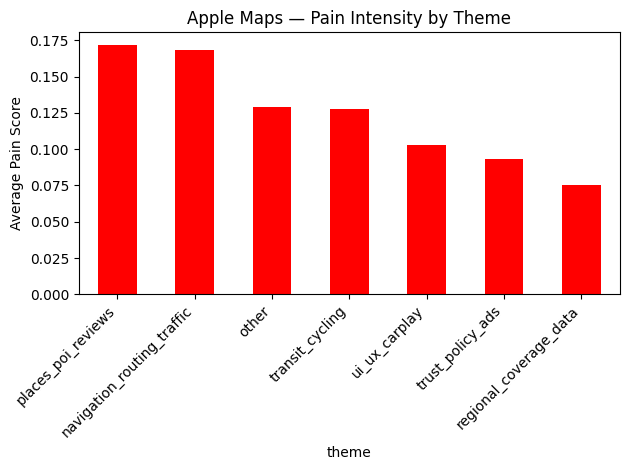

In [33]:
import matplotlib.pyplot as plt

theme_summary_reset = theme_summary.reset_index()

plt.figure(figsize=(9,5))
theme_summary_reset.sort_values("avg_pain_intensity", ascending=False).plot(
    x="theme",
    y="avg_pain_intensity",
    kind="bar",
    color="red",
    legend=False
)
plt.title("Apple Maps — Pain Intensity by Theme")
plt.ylabel("Average Pain Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [34]:
theme_summary_reset.sort_values("avg_neg_comment_rate", ascending=False)


,theme,posts,avg_post_sentiment,avg_neg_comment_rate,avg_consensus,avg_pain_intensity
5,trust_policy_ads,8,0.190175,0.140619,0.077477,0.092988
0,places_poi_reviews,33,0.159245,0.128114,0.273064,0.171912
2,other,59,0.082434,0.115537,0.214247,0.128795
1,navigation_routing_traffic,107,0.173224,0.107525,0.290833,0.168377
4,ui_ux_carplay,27,0.268452,0.100000,0.067747,0.102669
6,regional_coverage_data,8,0.044413,0.025000,0.181250,0.075285
3,transit_cycling,4,0.166175,0.000000,0.375000,0.127670
